# 06 - Over-smoothing & over-squashing

Intuition says "deeper = more context = better". For GNNs that's often **false**, for
two distinct reasons:

- **Over-smoothing**: each layer averages neighbourhoods, so after many layers *every*
  node embedding converges to the same vector - the signal washes out.
- **Over-squashing**: to reach a node `k` hops away you need `k` layers, but information
  from an exponentially growing neighbourhood gets crammed ("squashed") through narrow
  paths/bottlenecks into fixed-size vectors, and is lost.

Let's *measure* both, then fix over-smoothing.

In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))   # make utils/ importable from notebooks/

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
torch.manual_seed(0); np.random.seed(0)

from utils import graphs as G     # synthetic graph generators (known ground truth)
from utils import models as M     # the model zoo (MLP, GCN, SAGE, GAT, GIN, GPS, ...)
from utils import training as T    # train/eval loops + metrics
from utils import plotting as P    # graph drawing, curves, comparisons


## Over-smoothing: accuracy and signal collapse vs depth

We train plain GCNs of increasing depth on the SBM, and separately measure the
**Dirichlet energy** of the embeddings - $\sum_{(i,j)\in E}\lVert h_i - h_j\rVert^2$,
which -> 0 as neighbours become identical. Both should fall off a cliff as depth grows.

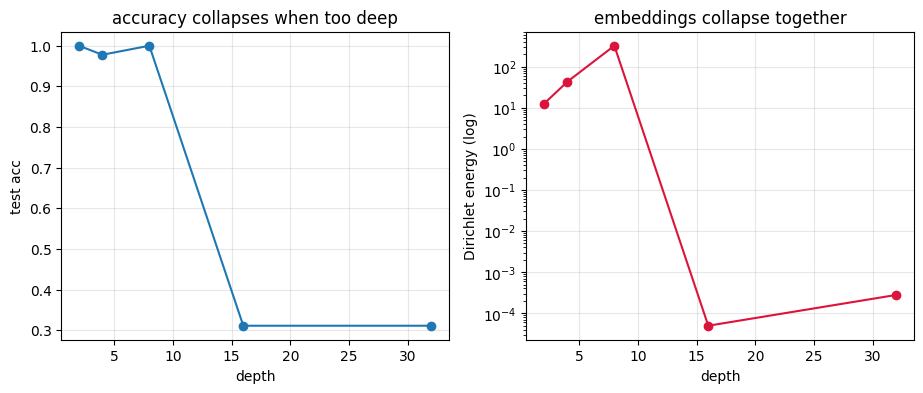

,depth,test acc,dirichlet energy
0,2,1.000,1.250e+01
1,4,0.978,4.338e+01
2,8,1.000,3.255e+02
3,16,0.311,0.000e+00
4,32,0.311,3.000e-04


In [2]:
data, gt = G.make_sbm_homophily(homophily=0.85, seed=1)
C = int(data.y.max())+1
depths = [2, 4, 8, 16, 32]

acc, energy = [], []
for L in depths:
    T.set_seed(0)
    m = M.GNN(data.num_features, 32, C, conv="gcn", n_layers=L, dropout=0.0)
    r = T.train_node(m, data, task="classification", epochs=150)
    acc.append(r["test_metric"])
    m.eval()
    with torch.no_grad():
        h = data.x
        for conv in m.convs:
            h = torch.relu(conv(h, data.edge_index))
    energy.append(T.dirichlet_energy(h, data.edge_index))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(depths, acc, "o-"); ax[0].set_xlabel("depth"); ax[0].set_ylabel("test acc")
ax[0].set_title("accuracy collapses when too deep"); ax[0].grid(alpha=.3)
ax[1].semilogy(depths, energy, "o-", color="crimson"); ax[1].set_xlabel("depth")
ax[1].set_ylabel("Dirichlet energy (log)"); ax[1].set_title("embeddings collapse together"); ax[1].grid(alpha=.3)
plt.show()
pd.DataFrame({"depth": depths, "test acc": acc, "dirichlet energy": energy}).round(4)

## Fixing over-smoothing: PairNorm, residuals, Jumping-Knowledge

Three standard remedies, all available as knobs on `utils/models.py:GNN`:

- **Residual connections** (`residual=True`): keep a copy of each node's own signal.
- **PairNorm** (`norm="pair"`): rescale after each layer so total variance is preserved.
- **Jumping-Knowledge** (`jk=True`): concatenate *all* layers' outputs, so early
  (sharp) and late (smooth) representations are both available to the readout.

We rerun a **deep (16-layer)** GCN with these on.

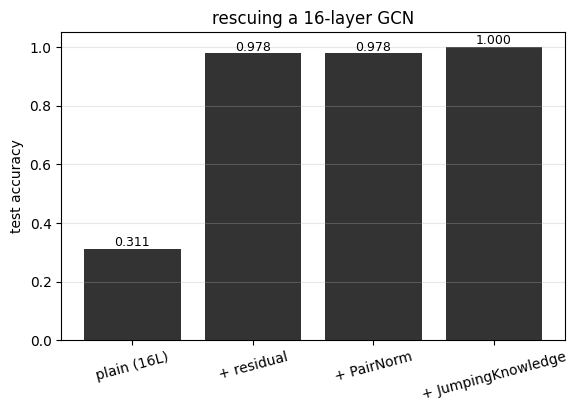

In [3]:
variants = {
    "plain (16L)":        dict(),
    "+ residual":         dict(residual=True),
    "+ PairNorm":         dict(norm="pair"),
    "+ JumpingKnowledge": dict(jk=True),
}
res = {}
for name, kw in variants.items():
    T.set_seed(0)
    m = M.GNN(data.num_features, 32, C, conv="gcn", n_layers=16, dropout=0.0, **kw)
    res[name] = T.train_node(m, data, task="classification", epochs=150)["test_metric"]
fig, ax = plt.subplots(figsize=(6.5,4))
P.bar_compare({k: {"test_metric": v} for k, v in res.items()},
              title="rescuing a 16-layer GCN", ylabel="test accuracy", ax=ax)
plt.xticks(rotation=15); plt.show()

## Over-squashing: the RingTransfer bottleneck

Different problem, different cure. In `make_ring_transfer`, the answer sits `ring_size/2`
hops from the source node that must read it. A `k`-layer GNN with `k <` distance **cannot
even in principle** solve it; and as the ring grows the long thin path squashes the
signal. We hold the model depth fixed and grow the ring - accuracy decays toward chance.

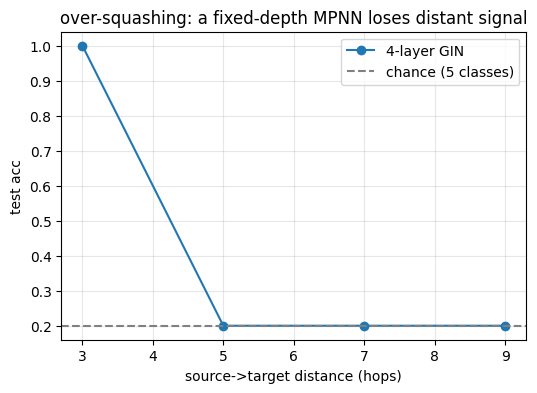

In [4]:
ring_sizes = [6, 10, 14, 18]
accs = []
for rs in ring_sizes:
    graphs, gtr = G.make_ring_transfer(num_graphs=500, ring_size=rs, num_classes=5, seed=0)
    loaders = T.make_graph_loaders(graphs, batch_size=64, seed=0)
    T.set_seed(0)
    m = M.GraphGNN(graphs[0].num_features, 32, 5, conv="gin", n_layers=4, pool="source")
    accs.append(T.train_graph(m, loaders, epochs=40)["test_metric"])

plt.figure(figsize=(6,4))
plt.plot([r//2 for r in ring_sizes], accs, "o-", label="4-layer GIN")
plt.axhline(0.2, ls="--", color="gray", label="chance (5 classes)")
plt.xlabel("source->target distance (hops)"); plt.ylabel("test acc")
plt.title("over-squashing: a fixed-depth MPNN loses distant signal"); plt.legend(); plt.grid(alpha=.3)
plt.show()

## Takeaways

- **Deeper is not automatically better.** Diagnose over-smoothing with Dirichlet energy;
  cure it with residuals / PairNorm / Jumping-Knowledge (or just don't go very deep).
- **Over-squashing** is about *bottlenecks and distance*, not smoothing - fixes are
  **graph rewiring** (add shortcut edges), a **virtual/global node**, or **global
  attention**.
- That last fix - letting any node talk to any node in one step - is exactly the **graph
  transformer** in notebook 08.